# Checkout redesign: should we ship it?

**Audience:** product and commercial leads. No statistics background needed.

**The question.** We redesigned the checkout page. For four weeks, every visitor who reached checkout was
randomly shown either the current page (*control*) or the redesign (*treatment*). Did the redesign make more
people complete their purchase, and is the gain big enough to be worth shipping?

**How we decide.** Before the test started we wrote down the rules:

- **Primary metric:** conversion rate, the share of checkout visitors who place an order.
- **Secondary metric:** revenue per visitor.
- **Ship** only if the lift is statistically reliable (under a 5% chance it is noise) *and* at least +2%,
  the smallest gain worth the engineering and maintenance cost.
- **Look at the results once**, at the end, not every day.

The recommendation is at the bottom of this notebook.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import matplotlib.dates as mdates
from IPython.display import Markdown, display

from src import config
from src.analysis import (business_impact, load_user_outcomes, monthly_users, recommendation,
                          required_sample_size, simulate_peeking, srm_check)

CONTROL, TREATMENT, INK, MUTED, GRID = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
                     "axes.grid": True, "grid.color": GRID, "axes.axisbelow": True, "font.size": 10})

with duckdb.connect(str(config.WAREHOUSE), read_only=True) as con:
    users = load_user_outcomes(con)
    variants = con.sql("select * from fct_experiment_results order by variant_key").df()
    results = con.sql("select * from fct_test_results").df().set_index("metric")

control, treatment = users[users.variant == "control"], users[users.variant == "treatment"]


def say(text):
    """Render text as Markdown, escaping $ so amounts are not read as maths."""
    display(Markdown(text.replace("$", r"\$")))


variants[["variant_name", "users", "conversions", "conversion_rate", "revenue_per_user"]]

,variant_name,users,conversions,conversion_rate,revenue_per_user
0,control,24971,2470,0.098915,7.519570
1,treatment,25029,2758,0.110192,8.154135


## 1. Did we test on enough people?

A test that is too small can miss a real improvement. Before launch we asked: how many visitors does each
version need so that, if the redesign truly lifts conversion by 8%, we would detect it 8 times out of 10?

In [2]:
baseline = control.converted.mean()
needed = required_sample_size(baseline)
say((
    f"With a baseline conversion rate of **{baseline:.1%}**, each version needed **{needed:,} visitors**. "
    f"We got **{len(control):,}** (control) and **{len(treatment):,}** (treatment), so the test was big enough."
))

With a baseline conversion rate of **9.9%**, each version needed **23,128 visitors**. We got **24,971** (control) and **25,029** (treatment), so the test was big enough.

## 2. Can we trust the data?

We planned a 50/50 split. If the actual split is noticeably off, something went wrong with how visitors were
assigned or tracked (a *sample ratio mismatch*), and the results cannot be trusted no matter how good they
look. We check this with a chi-square test and only raise the alarm when the imbalance is extremely unlikely
to be chance (p below 0.001).

In [3]:
srm = srm_check(len(control), len(treatment))
verdict = "passed, the split is what random assignment would produce" if srm["passed"] else "FAILED, stop here"
say((
    f"Control received **{srm['control_share']:.2%}** of visitors and treatment **{1 - srm['control_share']:.2%}** "
    f"(p = {srm['p_value']:.2f}). Check **{verdict}**."
))

Control received **49.94%** of visitors and treatment **50.06%** (p = 0.80). Check **passed, the split is what random assignment would produce**.

## 3. Did the redesign lift conversion?

The chart shows how each version's conversion rate built up over the four weeks. Early on the lines jump
around because few visitors have been counted; they settle as data accumulates.

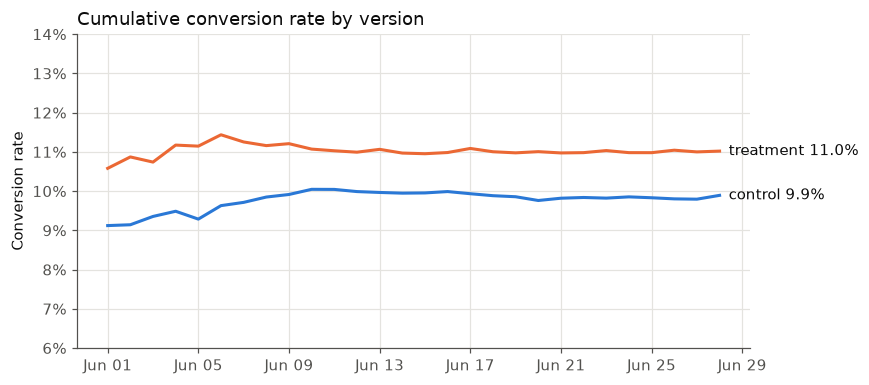

In [4]:
daily = (users.groupby(["assignment_date", "variant"])
              .agg(visitors=("user_id", "size"), orders=("converted", "sum"))
              .groupby(level="variant").cumsum()
              .reset_index())
daily["cumulative_rate"] = daily.orders / daily.visitors

fig, ax = plt.subplots(figsize=(8, 3.6))
for name, color in [("control", CONTROL), ("treatment", TREATMENT)]:
    d = daily[daily.variant == name]
    ax.plot(d.assignment_date, d.cumulative_rate, color=color, lw=2)
    ax.annotate(f"{name} {d.cumulative_rate.iloc[-1]:.1%}", (d.assignment_date.iloc[-1], d.cumulative_rate.iloc[-1]),
                xytext=(6, 0), textcoords="offset points", va="center", color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_ylim(0.06, 0.14)
ax.set_title("Cumulative conversion rate by version", loc="left", color=INK)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.set_xlabel(""); ax.set_ylabel("Conversion rate")
plt.tight_layout(); plt.show()

In [5]:
conv = results.loc["conversion_rate"]
rel_low, rel_high = conv.ci_low / conv.control_value, conv.ci_high / conv.control_value
say((
    f"- Current checkout: **{conv.control_value:.2%}** of visitors ordered.\n"
    f"- Redesign: **{conv.treatment_value:.2%}**.\n"
    f"- That is a **{conv.relative_lift:+.1%}** relative lift. The 95% range is **{rel_low:+.1%} to {rel_high:+.1%}**: "
    f"we are confident the true effect sits in there, and the whole range is above zero.\n"
    f"- The chance of seeing a gap this large if the redesign did nothing is "
    f"**{'below 0.0001' if conv.p_value < 0.0001 else f'{conv.p_value:.4f}'}** "
    f"(well under our 0.05 bar)."
))

- Current checkout: **9.89%** of visitors ordered.
- Redesign: **11.02%**.
- That is a **+11.4%** relative lift. The 95% range is **+6.0% to +16.8%**: we are confident the true effect sits in there, and the whole range is above zero.
- The chance of seeing a gap this large if the redesign did nothing is **below 0.0001** (well under our 0.05 bar).

> **A note on the size of the effect.** This dataset is simulated, and we built it with a true lift of +8%.
> The test measured more than that. That is normal: any single test lands somewhere inside its range, and
> the true +8% does sit inside it. It is also why we plan on the range, not just the headline number.

## 4. Did it lift revenue too?

More orders only matter if they bring money. Revenue per visitor is noisier than conversion, because order
sizes vary a lot, so its range is wider.

In [6]:
from src.analysis import welch_ttest

rev = results.loc["revenue_per_user"]
aov = welch_ttest(control.loc[control.converted == 1, "revenue"], treatment.loc[treatment.converted == 1, "revenue"])
aov_note = ("Average order size did not change in a statistically reliable way "
            f"(${aov['control']:.2f} vs ${aov['treatment']:.2f}, p = {aov['p_value']:.2f}), "
            "so the revenue gain comes from more people buying, not bigger baskets."
            if aov["p_value"] >= config.ALPHA else
            f"Average order size also changed (${aov['control']:.2f} vs ${aov['treatment']:.2f}, p = {aov['p_value']:.3f}).")
say((
    f"Revenue per visitor went from **${rev.control_value:.2f}** to **${rev.treatment_value:.2f}** "
    f"({rev.relative_lift:+.1%}, 95% range {rev.ci_low / rev.control_value:+.1%} to "
    f"{rev.ci_high / rev.control_value:+.1%}, p = {rev.p_value:.3f}). " + aov_note
))

Revenue per visitor went from **\$7.52** to **\$8.15** (+8.4%, 95% range +2.1% to +14.8%, p = 0.009). Average order size did not change in a statistically reliable way (\$76.02 vs \$74.00, p = 0.11), so the revenue gain comes from more people buying, not bigger baskets.

## 5. A sharper estimate with CUPED

Some visitors buy a lot, some rarely, regardless of which checkout they see. That background variation
blurs the comparison. CUPED uses each visitor's order count *from before the test* to subtract the part
of their behaviour we could already predict. The redesign could not have influenced pre-test orders, so
this keeps the estimate honest while making it more precise.

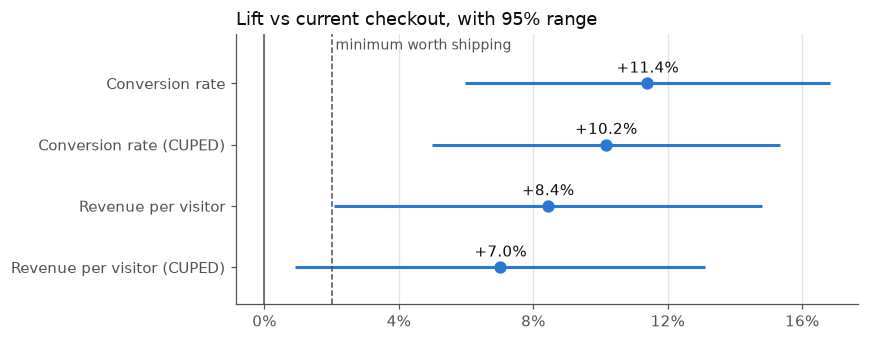

CUPED puts the conversion lift at **+10.2%** (95% range +5.0% to +15.4%). By chance, the treatment group contained slightly more frequent shoppers (2.12 vs 2.08 orders in the 90 days before the test); CUPED corrects for that imbalance. Both methods agree on the decision.

In [7]:
labels = {"conversion_rate": "Conversion rate", "conversion_rate_cuped": "Conversion rate (CUPED)",
          "revenue_per_user": "Revenue per visitor", "revenue_per_user_cuped": "Revenue per visitor (CUPED)"}
plot = results.loc[list(labels)].assign(low=lambda d: d.ci_low / d.control_value,
                                        high=lambda d: d.ci_high / d.control_value)

fig, ax = plt.subplots(figsize=(8, 3.2))
y = range(len(plot))[::-1]
ax.hlines(y, plot.low, plot.high, color=CONTROL, lw=2)
ax.scatter(plot.relative_lift, y, color=CONTROL, s=50, zorder=3)
for yi, (_, row) in zip(y, plot.iterrows()):
    ax.annotate(f"{row.relative_lift:+.1%}", (row.relative_lift, yi), xytext=(0, 7), textcoords="offset points",
                ha="center", color=INK)
ax.axvline(0, color=MUTED, lw=1)
ax.axvline(config.MIN_PRACTICAL_LIFT, color=MUTED, lw=1, ls="--")
ax.text(config.MIN_PRACTICAL_LIFT, len(plot) - 0.45, " minimum worth shipping", color=MUTED, fontsize=9)
ax.set_yticks(list(y), [labels[m] for m in plot.index])
ax.xaxis.set_major_locator(mtick.MultipleLocator(0.04))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_ylim(-0.6, len(plot) - 0.2)
ax.set_title("Lift vs current checkout, with 95% range", loc="left", color=INK)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

cuped = results.loc["conversion_rate_cuped"]
pre_c, pre_t = control.pre_period_orders.mean(), treatment.pre_period_orders.mean()
same = results.loc["conversion_rate", "decision"] == cuped.decision
say((
    f"CUPED puts the conversion lift at **{cuped.relative_lift:+.1%}** "
    f"(95% range {cuped.ci_low / cuped.control_value:+.1%} to {cuped.ci_high / cuped.control_value:+.1%}). "
    f"By chance, the {'treatment' if pre_t > pre_c else 'control'} group contained slightly more frequent shoppers "
    f"({max(pre_c, pre_t):.2f} vs {min(pre_c, pre_t):.2f} orders in the 90 days before the test); CUPED corrects for "
    f"that imbalance. {'Both methods agree on the decision.' if same else 'The two methods disagree, so treat the result with caution.'}"
))

## 6. Why we waited four weeks instead of checking daily

It is tempting to watch the dashboard every day and stop as soon as the redesign looks like a winner. The
problem: random noise makes the lines cross and uncross, and if you check often enough, one of those swings
will eventually look "significant".

To show this, we simulated thousands of tests where **both versions were identical** (so any "win" is false)
and checked each one daily for 28 days.

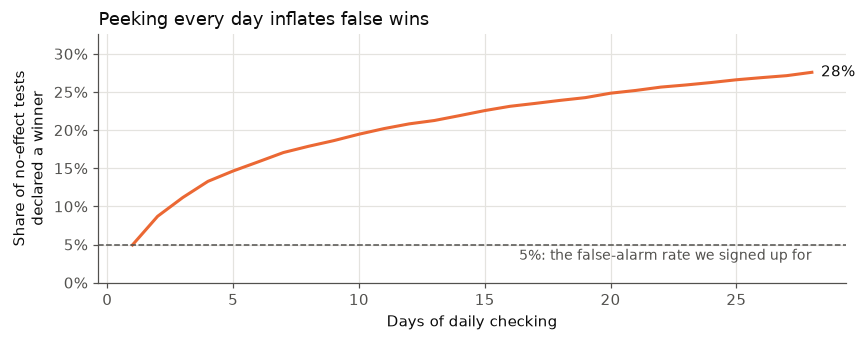

Checked once at the end, identical versions were wrongly called a winner **5.0%** of the time, right at the 5% we accept. Checked daily, that rose to **28%**. We fixed the test length in advance and read the result once, so our 5% guarantee holds.

In [8]:
peek = simulate_peeking()
fig, ax = plt.subplots(figsize=(8, 3.2))
days = range(1, peek["n_looks"] + 1)
ax.plot(days, peek["fpr_by_look"], color=TREATMENT, lw=2)
ax.axhline(config.ALPHA, color=MUTED, lw=1, ls="--")
ax.text(peek["n_looks"], config.ALPHA - 0.02, "5%: the false-alarm rate we signed up for", color=MUTED,
        fontsize=9, ha="right")
ax.annotate(f"{peek['fpr_peeking']:.0%}", (peek["n_looks"], peek["fpr_peeking"]), xytext=(6, 0),
            textcoords="offset points", va="center", color=INK)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1, decimals=0))
ax.set_ylim(0, peek["fpr_peeking"] + 0.05)
ax.set_xlabel("Days of daily checking"); ax.set_ylabel("Share of no-effect tests\ndeclared a winner")
ax.set_title("Peeking every day inflates false wins", loc="left", color=INK)
plt.tight_layout(); plt.show()

say((
    f"Checked once at the end, identical versions were wrongly called a winner **{peek['fpr_fixed_horizon']:.1%}** "
    f"of the time, right at the 5% we accept. Checked daily, that rose to **{peek['fpr_peeking']:.0%}**. "
    "We fixed the test length in advance and read the result once, so our 5% guarantee holds."
))

## 7. Recommendation

In [9]:
impact = business_impact(results.reset_index(), monthly_users(users))
say((f"### {conv.decision}\n\n{recommendation(results.reset_index(), impact)}"))

pd.DataFrame({
    "Expected": [f"{impact['extra_orders']:,.0f}", f"${impact['extra_revenue']:,.0f}"],
    "Low end (95%)": [f"{impact['extra_orders_low']:,.0f}", f"${impact['extra_revenue_low']:,.0f}"],
    "High end (95%)": [f"{impact['extra_orders_high']:,.0f}", f"${impact['extra_revenue_high']:,.0f}"],
}, index=["Extra orders per month", "Extra revenue per month"])

### Ship

Ship the new checkout. It lifts conversion by +11.4% (95% range +6.0% to +16.8%), which means roughly 604 extra orders and about \$33,995 more revenue per month (likely between \$8,317 and \$59,672).

,Expected,Low end (95%),High end (95%)
Extra orders per month,604,317,891
Extra revenue per month,"$33,995","$8,317","$59,672"


In [10]:
say((f"""
**How the monthly figures are calculated.** The test covered all checkout traffic for
{users.assignment_date.nunique()} days, which is about **{impact['users_per_month']:,.0f} checkout visitors per
month**. Extra orders = visitors x the conversion lift; extra revenue = visitors x the revenue-per-visitor lift.
{"The low end is still positive, so even the cautious reading favours shipping." if impact["extra_revenue_low"] > 0 else "The low end includes zero or a loss, so the revenue case is less certain than the conversion case."}

**Why this is a sound decision**

- The traffic split was healthy, so the data is trustworthy.
- The test was large enough and we looked only once, at the pre-agreed end date.
- The lift is both statistically reliable and above the +2% bar we set for "worth it". A statistically
  significant +0.5% would *not* have passed.
- Revenue moved in the same direction as conversion, and results hold after the CUPED adjustment.

**Next steps:** roll out to 100% of traffic, then keep tracking conversion for a few weeks to confirm the
gain holds once the novelty wears off.
"""))


**How the monthly figures are calculated.** The test covered all checkout traffic for
28 days, which is about **53,571 checkout visitors per
month**. Extra orders = visitors x the conversion lift; extra revenue = visitors x the revenue-per-visitor lift.
The low end is still positive, so even the cautious reading favours shipping.

**Why this is a sound decision**

- The traffic split was healthy, so the data is trustworthy.
- The test was large enough and we looked only once, at the pre-agreed end date.
- The lift is both statistically reliable and above the +2% bar we set for "worth it". A statistically
  significant +0.5% would *not* have passed.
- Revenue moved in the same direction as conversion, and results hold after the CUPED adjustment.

**Next steps:** roll out to 100% of traffic, then keep tracking conversion for a few weeks to confirm the
gain holds once the novelty wears off.
